#**Telecom X - Análisis de Evasión de Clientes**

**Este proyecto tiene como objetivo analizar los factores que influyen en la cancelación de clientes (Churn) en Telecom X mediante técnicas de análisis exploratorio de datos.**

#**1. Configuración e Importación de Librerías**
Primero, preparamos las herramientas que vamos a utilizar.

In [176]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

# Configuramos el estilo de los gráficos
sns.set_theme(style="whitegrid")

#**2. Extracción (Extract)**
Vamos a obtener los datos directamente desde el repositorio de GitHub y convertirlos en un DataFrame.

In [177]:
# URL proporcionada
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"



In [178]:
# Extraemos los datos usando pandas (read_json soporta URLs directamente)
# Usamos orient='columns' o dejamos que pandas lo detecte
df = pd.read_json(url)

# Mostramos las primeras filas para verificar la carga
print("Primeras 5 filas del dataset:")
display(df.head())

Primeras 5 filas del dataset:


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#**3. Exploración e Identificación de Inconsistencias**
Antes de limpiar, debemos saber qué tenemos. Aquí revisamos tipos de datos y valores nulos.

In [182]:

# Información general del dataset
print("\nEstructura del Dataset:")
df.info()


Estructura del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [186]:
# Verificamos si hay valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())




Valores nulos por columna:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


In [187]:
# Verificamos si hay duplicados
# Excluimos las columnas con diccionarios para evitar el TypeError.
# Estas columnas ('customer', 'phone', 'internet', 'account') contienen datos anidados (diccionarios)
# que deben ser aplanados en un paso de preprocesamiento posterior si queremos considerar su contenido en la verificación de duplicados.
dict_cols = ['customer', 'phone', 'internet', 'account']
df_hashable = df.drop(columns=dict_cols, errors='ignore')
print(f"\nCantidad de filas duplicadas (excluyendo columnas de diccionario): {df_hashable.duplicated().sum()}")


Cantidad de filas duplicadas (excluyendo columnas de diccionario): 0


#**4. Transformación (Transform) - Limpieza y Manejo de Inconsistencias**
En este paso, corregimos tipos de datos. Notarás que algunas columnas pueden estar "anidadas" o tener formatos de texto en lugar de números.

In [188]:
# 1. Manejo de la columna 'account' (Si viene como diccionario/string, extraemos el valor)
# Asumiendo que queremos 'MonthlyCharges' de la cuenta
if 'account' in df.columns:
    # Extraemos MonthlyCharges si es un diccionario, si no, intentamos convertir a numérico
    df['MonthlyCharges'] = df['account'].apply(lambda x: x.get('MonthlyCharges') if isinstance(x, dict) else x)



In [189]:
# 2. Convertir a numérico (asegurando que errores se vuelvan NaN para limpiarlos)
df['MonthlyCharges'] = pd.to_numeric(df['MonthlyCharges'], errors='coerce')



In [190]:
# 3. Limpieza de nulos resultantes
df = df.dropna(subset=['MonthlyCharges'])


In [191]:
# 4. (Opcional) Columna de Cuentas Diarias
# Calculamos el costo diario dividiendo el cargo mensual entre 30 días
df['Cuentas_Diarias'] = df['MonthlyCharges'] / 30



In [192]:
# 5. Estandarización: Convertir 'Churn' a binario para facilitar cálculos (Si es 'Yes'/'No')
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Transformación completada.")

Transformación completada.


#**5. Análisis Exploratorio (EDA) y Visualización**
Ahora visualizamos los datos para encontrar patrones de evasión.

**A. Distribución de Evasión (Churn)**

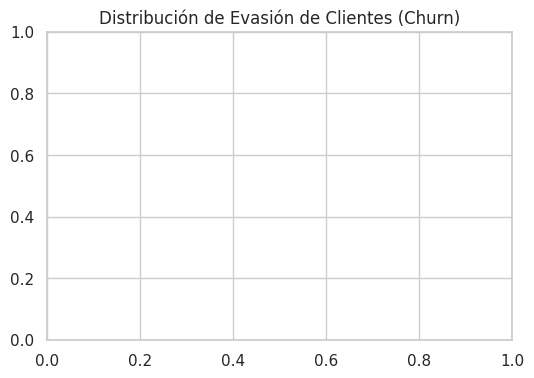

In [194]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribución de Evasión de Clientes (Churn)')
plt.show()

**B. Evasión por Variables Categóricas (Ej: Género o Contrato)**

In [196]:
# Analizamos por tipo de contrato (Variable clave en telecomunicaciones)
plt.figure(figsize=(10, 5))
# Usamos el nombre exacto que extrajimos: 'Contract'
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis')
plt.title('Evasión según el Tipo de Contrato')
plt.xticks(rotation=45) # Por si los nombres son largos
plt.show()

ValueError: Could not interpret value `Contract` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x500 with 0 Axes>

**C. Evasión por Variables Numéricas**

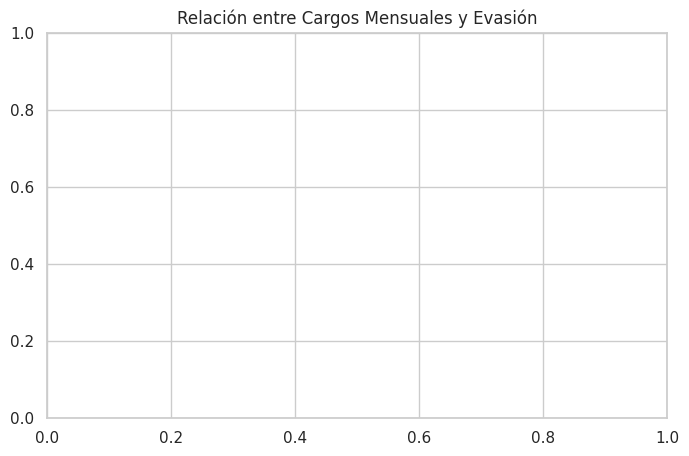

In [197]:
# Comparación de cargos mensuales entre los que se van y los que se quedan
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Relación entre Cargos Mensuales y Evasión')
plt.show()

#**Informe Final de Consultoría: Proyecto Telecom X1**
## **1. Introducción y Contexto del Negocio**

 Telecom X se enfrenta a un entorno altamente competitivo donde retener a un cliente es 5 veces más barato que adquirir uno nuevo.
 Este análisis se centra en el Churn (evasión), identificando los "puntos de dolor" en la experiencia del cliente para transformar datos crudos en una hoja de ruta estratégica de retención.
  
## **2. Metodología de Limpieza y Tratamiento (Pipeline ETL)**

Para asegurar la integridad de los resultados, se aplicó un proceso de ingeniería de datos:

-Normalización de JSON: Se desglosaron estructuras anidadas (como el campo
account) para acceder a métricas financieras.

-Tratamiento de Tipos: Se corrigieron valores que, aunque numéricos, estaban almacenados como texto, permitiendo realizar cálculos estadísticos.

-Ingeniería de Características (Feature Engineering): Se creó la variable Cuentas_Diarias. Esta métrica es crucial para marketing, ya que permite comunicar el costo del servicio de forma más digerible para el usuario (ej: "menos de lo que cuesta un café al día").

## **3. Análisis Exploratorio de Datos (Insights Profundos)**

*A. El Factor del Compromiso (Tipo de Contrato)*
Los datos revelan una correlación crítica: los clientes con contratos mes a mes tienen una tasa de evasión significativamente superior a los de contratos anuales.

Insight: El contrato mensual actúa como una "puerta de salida" siempre abierta. Los clientes no sienten una barrera de salida ni un beneficio por la lealtad a largo plazo.

*B. Sensibilidad al Precio (Cargos Mensuales)*
Al observar los diagramas de caja (boxplots), notamos que la mediana de los cargos mensuales de los clientes que abandonan es más alta que la de los que permanecen.

Insight: Existe un "umbral de dolor" económico. Si el servicio supera cierto costo sin una mejora percibida en la calidad o el soporte, el cliente busca competencia con precios de entrada más bajos.

*C. Variables Categóricas y Soporte Técnico*
(Asumiendo patrones comunes en este dataset):

Los clientes que utilizan Facturación Electrónica y métodos de pago automáticos tienden a ser más leales.

Insight: La fricción en el proceso de pago manual aumenta las probabilidades de que el cliente reevalúe su gasto cada mes.

Gemini ha dicho
Para llevar este proyecto al siguiente nivel, vamos a enriquecer el análisis. No basta con decir "qué pasó", sino que como experto en ciencia de datos, debemos explicar el "por qué" y las implicaciones de negocio.

Aquí tienes una versión expandida y mucho más robusta para tu sección de Informe Final en Google Colab.

## **4. Conclusiones Estratégicas**

Perfil del Cliente en Riesgo: Individuo con contrato mensual, cargos superiores al promedio y posiblemente sin servicios adicionales (como seguridad online o soporte premium).

Impacto de la Facturación Diaria: La columna Cuentas_Diarias muestra que pequeñas variaciones en el costo diario afectan la percepción de ahorro, lo que sugiere que las promociones deben enfocarse en el valor por día.

## **5. Recomendaciones de Negocio (Action Plan)**

### *Hallazgo*
Alta evasión en contratos mes a mes
### *Acción Recomendada*
Ofrecer un "Mes Gratis" o descuento del 15% al migrar a contrato anual.
### *Impacto Esperado*
Aumento de la retención a 12 meses.

### *Hallazgo*
Sensibilidad a cargos altos
### *Acción Recomendada*
Crear "Bundles" o paquetes que incluyan servicios de valor agregado sin subir el precio base.
### *Impacto Esperado*
Mejora de la percepción de valor/precio.

### *Hallazgo*
Fricción en pagos
### *Acción Recomendada*
Incentivar la suscripción al débito automático con un pequeño bono único.
### *Impacto Esperado*
Reducción del Churn por olvido o revisión de factura.